# Importar librerías necesarias

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


#  Cargar datos del CSV

In [2]:
data = pd.read_csv('cardio_data_processed.csv')
print("Tamaño de la base de datos:", data.shape)
data.head()

Tamaño de la base de datos: (68205, 17)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   68205 non-null  int64  
 1   age                  68205 non-null  int64  
 2   gender               68205 non-null  int64  
 3   height               68205 non-null  int64  
 4   weight               68205 non-null  float64
 5   ap_hi                68205 non-null  int64  
 6   ap_lo                68205 non-null  int64  
 7   cholesterol          68205 non-null  int64  
 8   gluc                 68205 non-null  int64  
 9   smoke                68205 non-null  int64  
 10  alco                 68205 non-null  int64  
 11  active               68205 non-null  int64  
 12  cardio               68205 non-null  int64  
 13  age_years            68205 non-null  int64  
 14  bmi                  68205 non-null  float64
 15  bp_category          68205 non-null 

In [4]:
print("-Valores nulos por columna:\n", data.isnull().sum())
print("\n-Valores duplicados:", data.duplicated().sum())

-Valores nulos por columna:
 id                     0
age                    0
gender                 0
height                 0
weight                 0
ap_hi                  0
ap_lo                  0
cholesterol            0
gluc                   0
smoke                  0
alco                   0
active                 0
cardio                 0
age_years              0
bmi                    0
bp_category            0
bp_category_encoded    0
dtype: int64

-Valores duplicados: 0


En esta parte revisamos si hay algún datos faltante en las columnas. En este caso no hay valores nulos en ninguna columna, así que no hay necesidad de imputar datos.


## Ver la distribución de la columna objetivo

0    34533
1    33672
Name: cardio, dtype: int64


<Axes: >

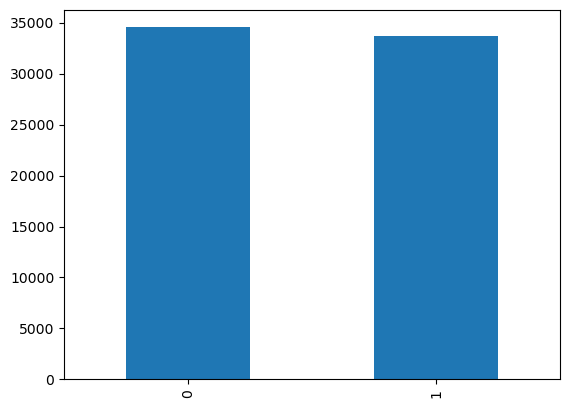

In [5]:
print(data["cardio"].value_counts())
data["cardio"].value_counts().plot(kind="bar")

In [6]:
# Eliminar columnas innecesarias
data = data.drop(columns=["id", "age","bp_category"])

En este dataset hay columnas que no se requieren en los modelos de machine learning, como la columna de "id", la columna de edad, ya que la edad se muestra en días y ya existe otra columna llamada "age_years" que la muestra en años enteros, y la columna "bp_category" que muestra la categoría de presión arterial, pero ya hay otra columna que tiene esos valores codificados para los modelos.

## Identificar valores atípicos

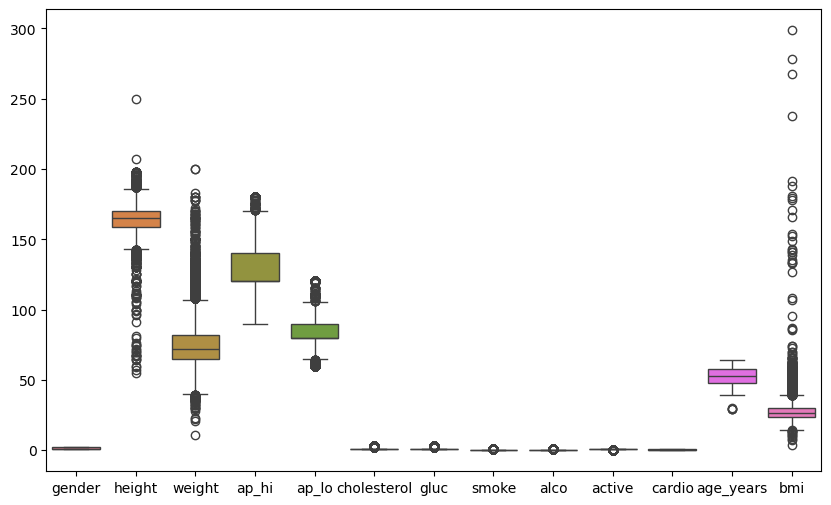

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)
plt.show()

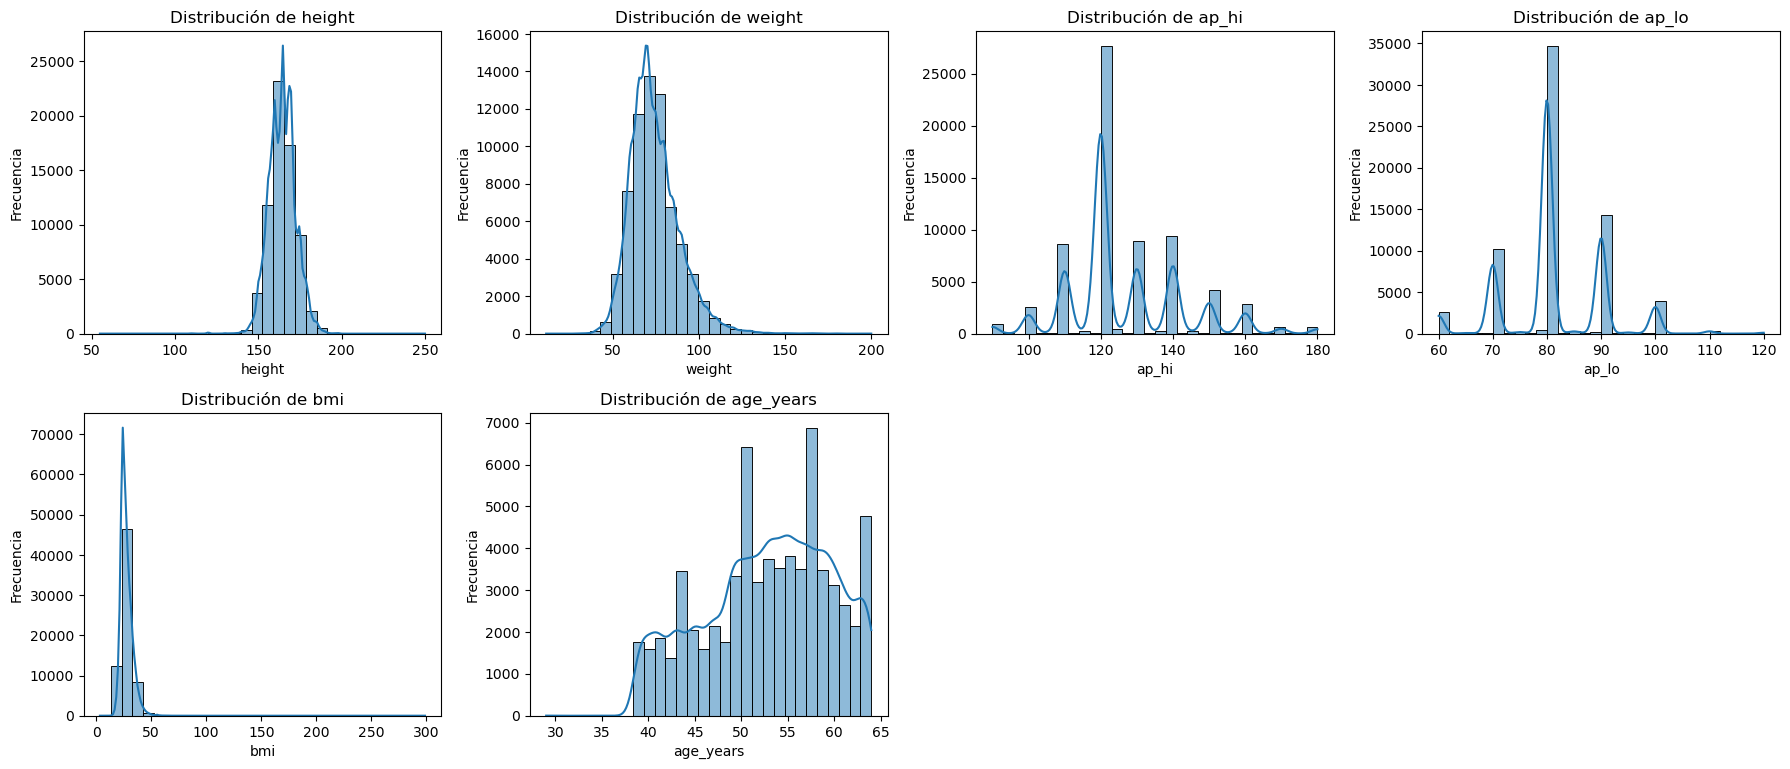

In [8]:
# Crear histogramas para cada variable numérica
plt.figure(figsize=(18, 15))

datos_numericos = data[["height", "weight", "ap_hi", "ap_lo", "bmi", "age_years"]]

# Crear histogramas
for i, columna in enumerate(datos_numericos, 1):
    plt.subplot(4, 4, i)
    
    sns.histplot(data[columna], kde=True, bins=30)
    
    plt.title(f'Distribución de {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')

# Ajustar espacios
plt.tight_layout()

# Mostrar gráficas
plt.show()

In [9]:
# Corregir valores imposibles en las columnas numéricas
data = data[(data["height"] >= 120) & (data["height"] <= 220)]
data = data[(data["weight"] >= 30) & (data["weight"] <= 250)]
data = data[(data["ap_hi"] >= 70) & (data["ap_hi"] <= 250)]
data = data[(data["ap_lo"] >= 40) & (data["ap_lo"] <= 180)]


In [10]:
# Eliminar valores atípicos usando el método Z-score
from scipy import stats

z_scores = np.abs(stats.zscore(datos_numericos, nan_policy='omit'))
outliers = data[(z_scores > 3).any(axis=1)]
data = data[~(z_scores > 3).any(axis=1)]
print("Número de outliers eliminados:", len(outliers))

Número de outliers eliminados: 1954


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_24748\1363425923.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers = data[(z_scores > 3).any(axis=1)]
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_24748\1363425923.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = data[~(z_scores > 3).any(axis=1)]


In [11]:
# Mostrar el tamaño de la base de datos después de eliminar valores atípicos
data.shape

(66196, 14)

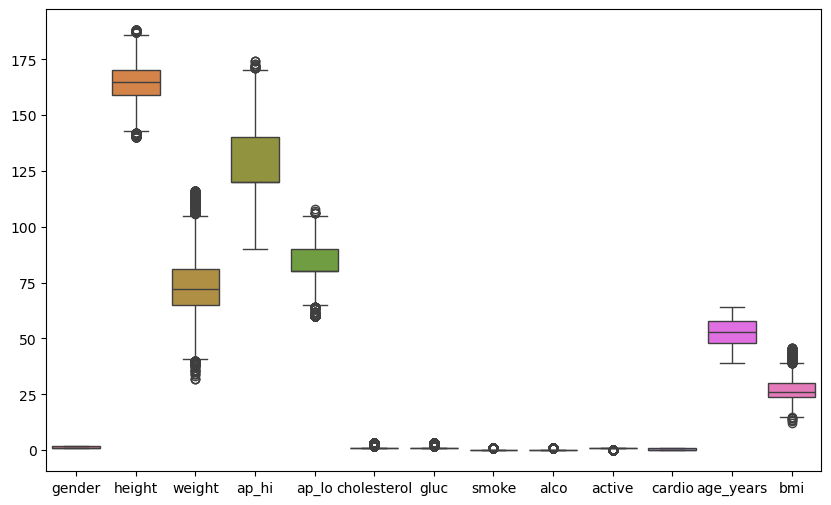

In [12]:
# Ver las distribuciones de las variables numéricas después de la limpieza
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)
plt.show()

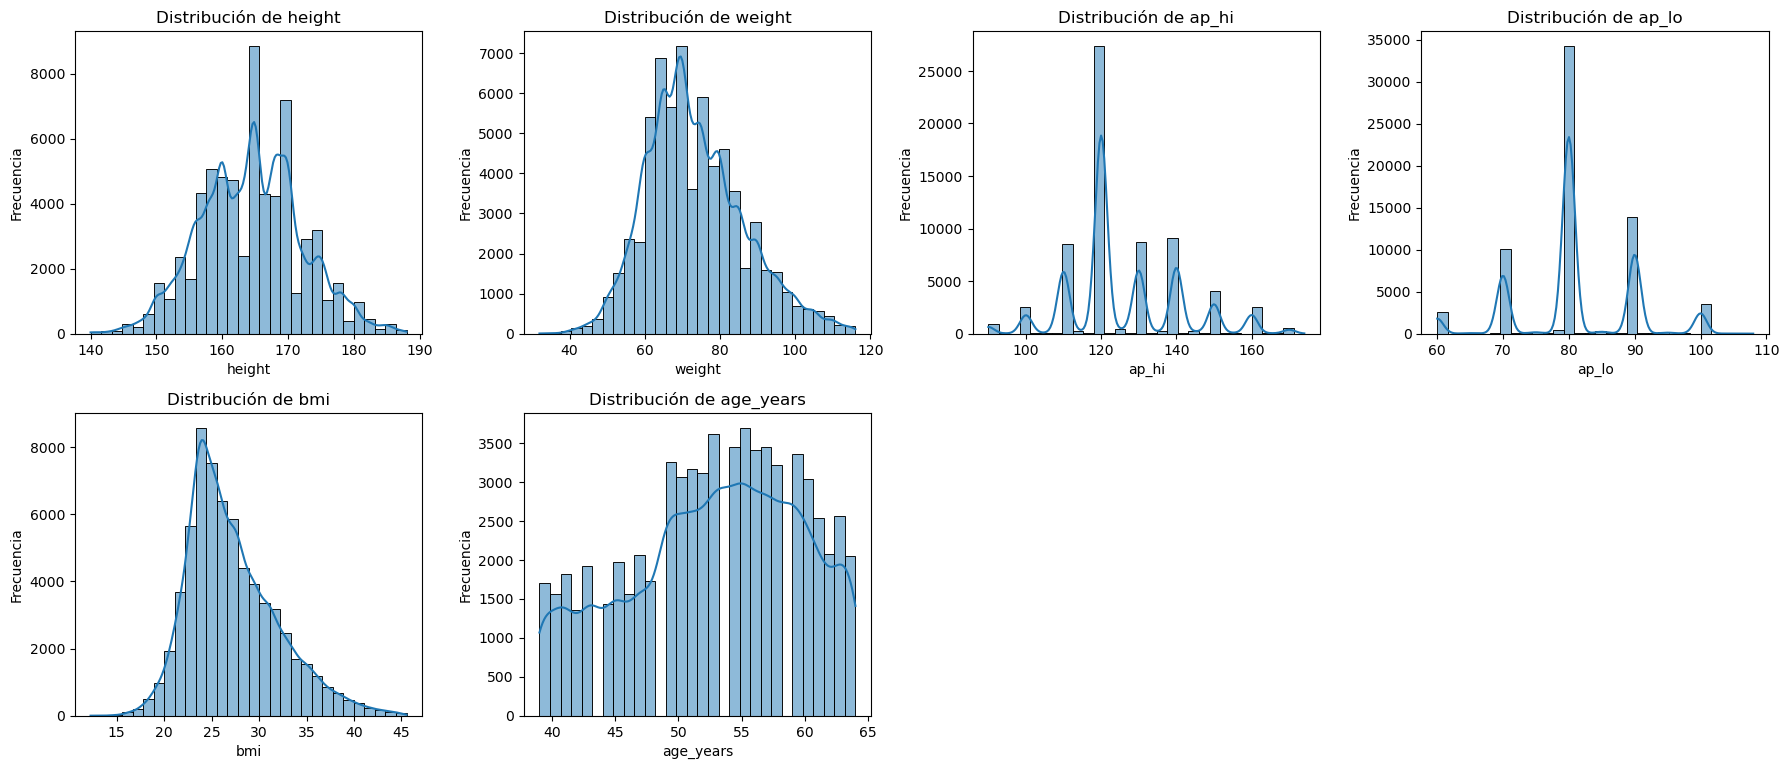

In [13]:
# Crear histogramas para cada variable numérica
plt.figure(figsize=(18, 15))

# Crear histogramas
for i, columna in enumerate(datos_numericos, 1):
    plt.subplot(4, 4, i)
    
    sns.histplot(data[columna], kde=True, bins=30)
    
    plt.title(f'Distribución de {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')

# Ajustar espacios
plt.tight_layout()

# Mostrar gráficas
plt.show()

## Codificación de variables

In [14]:
# Cambiar etiquetas de la columna 'gender', de 1 y 2 a 0 y 1 
data['gender'] = data['gender'].replace({1: 0, 2: 1})

# One-hot encoding para las variables 'cholesterol' y 'gluc'
data = pd.get_dummies(data, columns=['cholesterol', 'gluc'], prefix=['cholesterol', 'gluc'])

data.head()

,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio,age_years,bmi,bp_category_encoded,cholesterol_1,cholesterol_2,cholesterol_3,gluc_1,gluc_2,gluc_3
0,1,168,62.0,110,80,0,0,1,0,50,21.967120,Hypertension Stage 1,1,0,0,1,0,0
1,0,156,85.0,140,90,0,0,1,1,55,34.927679,Hypertension Stage 2,0,0,1,1,0,0
2,0,165,64.0,130,70,0,0,0,1,51,23.507805,Hypertension Stage 1,0,0,1,1,0,0
3,1,169,82.0,150,100,0,0,1,1,48,28.710479,Hypertension Stage 2,1,0,0,1,0,0
4,0,156,56.0,100,60,0,0,0,0,47,23.011177,Normal,1,0,0,1,0,0


## Escalamiento de datos

In [15]:
# Aplicar StandardScaler a las variables numéricas
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columnas_numericas = datos_numericos.columns
data[columnas_numericas] = scaler.fit_transform(data[columnas_numericas])
data.head()

,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio,age_years,bmi,bp_category_encoded,cholesterol_1,cholesterol_2,cholesterol_3,gluc_1,gluc_2,gluc_3
0,1,0.470171,-0.873451,-1.046104,-0.101094,0,0,1,0,-0.414547,-1.097985,Hypertension Stage 1,1,0,0,1,0,0
1,0,-1.097398,0.894889,0.958655,1.053057,0,0,1,1,0.323978,1.634034,Hypertension Stage 2,0,0,1,1,0,0
2,0,0.078279,-0.719682,0.290402,-1.255244,0,0,0,1,-0.266842,-0.773217,Hypertension Stage 1,0,0,1,1,0,0
3,1,0.600802,0.664236,1.626907,2.207207,0,0,1,1,-0.709957,0.323480,Hypertension Stage 2,1,0,0,1,0,0
4,0,-1.097398,-1.334757,-1.714357,-2.409395,0,0,0,0,-0.857662,-0.877904,Normal,1,0,0,1,0,0


## Guardar dataset limpio para las predicciones

In [16]:
data.to_csv('cardio_data_cleaned.csv', index=False)